# 📊 Football Visualizations using `mplsoccer`
This notebook demonstrates how to create team heatmap

In [2]:
# Import libraries
import pandas as pd
import matplotlib
from mplsoccer import Pitch, VerticalPitch
import matplotlib.pyplot as plt

In [12]:
# Read CSV file
df = pd.read_csv('barca_valladolid.csv')
df.head()

,id,eventId,minute,second,teamId,x,y,period,type,outcome,playerId,endX,endY
0,2248226915,2,0,0.0,Barcelona,0.0,0.0,1,Start,Successful,NaN,NaN,NaN
1,2248226919,2,0,0.0,Valladolid,0.0,0.0,1,Start,Successful,NaN,NaN,NaN
2,2248226929,3,0,1.0,Barcelona,50.0,50.0,1,Pass,Successful,9.0,43.9,46.9
3,2248226941,4,0,2.0,Barcelona,43.8,46.9,1,Pass,Successful,8.0,36.4,56.0
4,2248226951,5,0,4.0,Barcelona,36.6,56.6,1,Pass,Successful,21.0,28.5,73.8


# Team Heatmap

In [13]:
dfBarca = df[(df['teamId'] == 'Barcelona') & (df['outcome'] == 'Successful')]

In [8]:
customcmap = matplotlib.colors.LinearSegmentedColormap.from_list('custom_cmap', ['black', 'red'])

<Axes: >

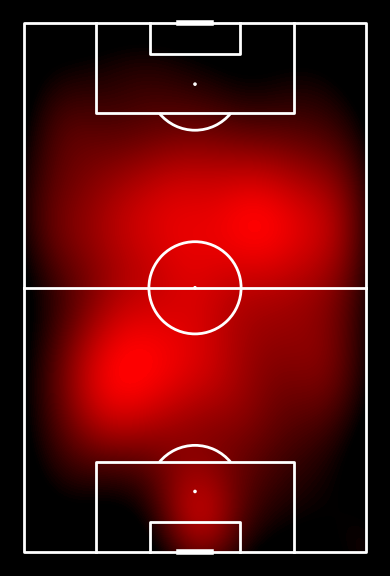

In [14]:
pitch = VerticalPitch(pitch_type='opta', pitch_color='black', 
                      line_color='white', line_zorder=2)
fig,ax = pitch.draw(figsize=(4, 8))
fig.set_facecolor('black')

# pitch.kdeplot(dfBarca['x'], dfBarca['y'], ax=ax, cmap='Reds', fill=True, n_levels=100)
pitch.kdeplot(dfBarca['x'], dfBarca['y'], ax=ax, cmap=customcmap, fill=True, n_levels=100, zorder=1)

# Player Heatmap

In [20]:
# Read CSV file
df1 = pd.read_csv('messibetis.csv')
df1.head()

,player,minute,second,x,y,type,outcome,endX,endY
0,messi,45,0,50,50,Pass,Successful,40,43
1,messi,45,25,63,48,Pass,Successful,75,83
2,messi,46,4,74,58,Pass,Successful,71,65
3,messi,46,7,76,68,Pass,Successful,95,78
4,messi,46,55,100,1,Pass,Unsuccessful,96,38


In [21]:
df1['type'].unique()

array(['Pass'], dtype=object)

In [ ]:
dfMessi = df1[df1['outcome'] == 'Successful']
# dfMessiPassMap = df1[(df1['outcome'] == 'Successful') & (df1['type'] == 'Pass')]

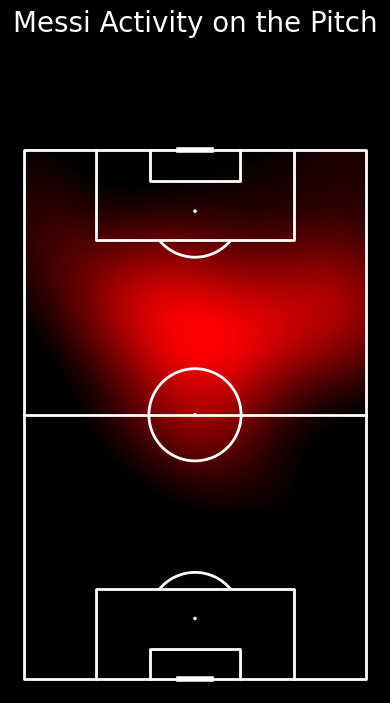

In [25]:
pitch = VerticalPitch(pitch_type='opta', pitch_color='black', 
                      line_color='white', line_zorder=2)
fig,ax = pitch.draw(figsize=(4, 8))
fig.set_facecolor('black')

pitch.kdeplot(dfMessi['x'], dfMessi['y'], 
              ax=ax, cmap=customcmap, 
              fill=True, n_levels=100, zorder=1)
fig.suptitle('Messi Activity on the Pitch', color='white', fontsize=20)
plt.show()